In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

df = pd.read_csv(r'clean_orders.csv')
print(df.shape)

(115723, 25)


In [2]:
# A/B Test: Does faster delivery lead to better review scores?
# Group A = delivered early or on time (delivery_delay_days <= 0)
# Group B = delivered late (delivery_delay_days > 0)

df_ab = df[['order_id', 'delivery_delay_days', 'review_score']].dropna()

group_a = df_ab[df_ab['delivery_delay_days'] <= 0]['review_score']  # on time
group_b = df_ab[df_ab['delivery_delay_days'] > 0]['review_score']   # late

print(f"Group A (On Time): {len(group_a):,} orders")
print(f"Group B (Late):    {len(group_b):,} orders")
print(f"\nGroup A Avg Review Score: {group_a.mean():.3f}")
print(f"Group B Avg Review Score: {group_b.mean():.3f}")

Group A (On Time): 108,157 orders
Group B (Late):    7,558 orders

Group A Avg Review Score: 4.211
Group B Avg Review Score: 2.323


In [8]:
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print("A/B TEST RESULTS")
print(f"T-Statistic:  {t_stat:.4f}")
print(f"P-Value:      {p_value:.6f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f" Results are significant(p < {alpha})")
    print("On-time delivery has a statistically significant")
    print("positive impact on customer review scores.")
else:
    print(f"Results are not significant(p >= {alpha})")
    print("No statistically significant difference found.")

A/B TEST RESULTS
T-Statistic:  125.7872
P-Value:      0.000000

 Results are significant(p < 0.05)
On-time delivery has a statistically significant
positive impact on customer review scores.


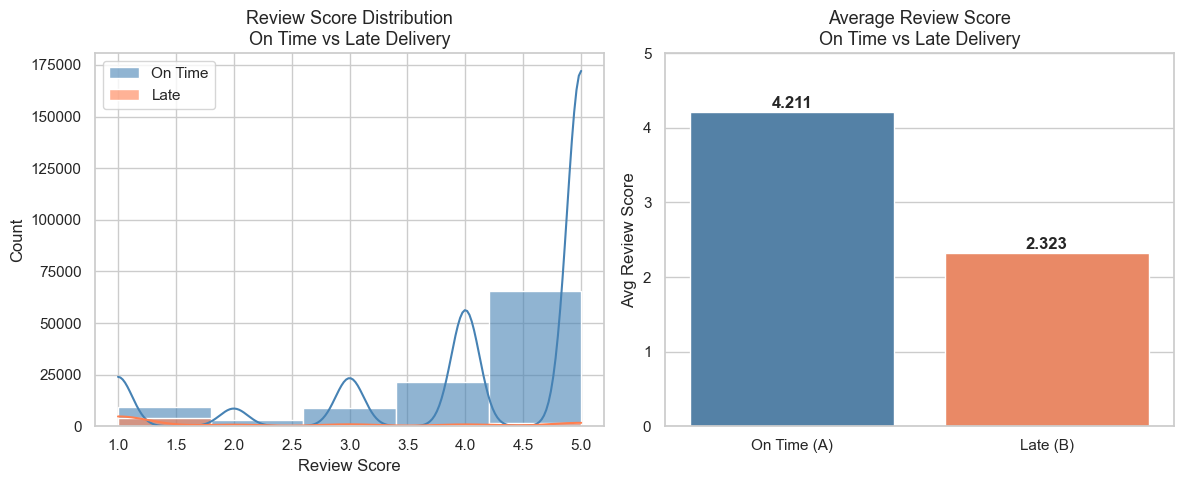

In [9]:
plt.figure(figsize=(12, 5))

# Plot 1 - Distribution comparison
plt.subplot(1, 2, 1)
sns.histplot(group_a, color='steelblue', label='On Time', kde=True, alpha=0.6, bins=5)
sns.histplot(group_b, color='coral', label='Late', kde=True, alpha=0.6, bins=5)
plt.title('Review Score Distribution\nOn Time vs Late Delivery', fontsize=13)
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.legend()

# Plot 2 - Average scores bar chart
plt.subplot(1, 2, 2)
avg_scores = pd.DataFrame({
    'Group': ['On Time (A)', 'Late (B)'],
    'Avg Review Score': [group_a.mean(), group_b.mean()]
})
sns.barplot(data=avg_scores, x='Group', y='Avg Review Score', palette=['steelblue', 'coral'], hue='Group', legend=False)
plt.title('Average Review Score\nOn Time vs Late Delivery', fontsize=13)
plt.xlabel('')
plt.ylabel('Avg Review Score')
plt.ylim(0, 5)

# Add value labels on bars
for i, row in avg_scores.iterrows():
    plt.text(i, row['Avg Review Score'] + 0.05, f"{row['Avg Review Score']:.3f}",
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\shirl\OneDrive\Desktop\ecommerce-analytics\data\ab_test_results.png', dpi=150)
plt.show()

In [10]:
# Cohen's d tells us HOW MEANINGFUL the difference is, not just if it exists
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return diff / pooled_std

d = cohens_d(group_a, group_b)

print(f"Cohen's d: {d:.4f}")
if abs(d) < 0.2:
    print("Effect size: SMALL")
elif abs(d) < 0.5:
    print("Effect size: MEDIUM")
else:
    print("Effect size: LARGE")

Cohen's d: 1.3176
Effect size: LARGE


In [11]:
print("A/B TEST SUMMARY")
print(f"Hypothesis:   On-time delivery → higher reviews")
print(f"Group A (On Time) — n={len(group_a):,}, mean={group_a.mean():.3f}")
print(f"Group B (Late)    — n={len(group_b):,}, mean={group_b.mean():.3f}")
print(f"Difference:   {group_a.mean() - group_b.mean():.3f} points")
print(f"P-Value:      {p_value:.6f}")
print(f"Cohen's d:    {d:.4f}")
if p_value < 0.05:
    print('Significant')
else:
    print("Not Significant")

A/B TEST SUMMARY
Hypothesis:   On-time delivery → higher reviews
Group A (On Time) — n=108,157, mean=4.211
Group B (Late)    — n=7,558, mean=2.323
Difference:   1.888 points
P-Value:      0.000000
Cohen's d:    1.3176
Significant
